---
title: Non-stationary GEV — a state-space GP trend
subtitle: A local linear trend (integrated random walk), the stochastic sibling of the ODE
short_title: Non-stationary (GP)
authors:
  - name: Juan Emmanuel Johnson
date: 2026-06-09
keywords:
  - non-stationary extremes
  - GEV
  - Gaussian process
  - state space model
  - local linear trend
  - NUTS
abstract: |
  The line committed to a shape; the ODE committed to a mechanism. The final
  model lets the data shape the trend — but with a *smoothness* prior tuned to
  resist over-fitting a single short record. We write the GEV location as
  $\mu(t)=\mu_0+f(t)$ with $f$ a Gaussian process in **state-space form**, and
  choose the **local linear trend** (an integrated random walk): the trend's
  *slope* random-walks, so draws default to a straight line and bend only where
  the data insist. It is a stochastic differential equation — the noise-driven
  sibling of the previous notebook's ODE — walked as a Markov chain in $O(n)$. We
  fit it with NUTS, show why a free stationary GP over-fits where this one does
  not, put line, ODE, and GP on one set of axes, and close the series.
---

# Non-stationary extremes: a state-space Gaussian process

Three notebooks, three answers to one question — *how does the GEV location move
through time?*

- [](10_nonstationary_parametric.ipynb): a **line**. Strong, interpretable, rigid.
- [](11_nonstationary_ode.ipynb): an **ODE**. A forced relaxation with physical
  memory $\tau$ — it can bend, but only in the one shape its mechanism allows.
- this notebook: a **Gaussian process**. A smoothness prior that lets the data
  shape the trend, while defaulting to a straight line where they are silent.

The GP is the natural endpoint, but two cautions shape the design. A textbook GP
over $n$ times needs an $n\times n$ covariance and $O(n^3)$ work — so we use the
**state-space** form, which is also conceptually perfect here: it turns the GP
into a *stochastic differential equation*, the direct generalisation of the ODE
we just fitted. And a *stationary* GP with a free lengthscale will happily chase
multidecadal wiggles and **over-fit** ~115 maxima — so we choose a trend prior
built to stay smooth.

## Background

### A GP prior on the trend

We model the location as a draw from a Gaussian process,

```{math}
:label: eq:gp-trend
\mu(t) = \mu_0 + f(t), \qquad f \sim \mathcal{GP}\!\bigl(0,\; k(t,t')\bigr).
```

The choice of covariance is the whole story. A *stationary* Matérn kernel with a
free lengthscale $\ell$ is flexible in both directions: give it a short $\ell$ and
it will track every multidecadal excursion in a century of annual maxima, fitting
noise as if it were trend. On a single short record that is over-fitting — we
demonstrate it below.

### The local linear trend

Instead we use the **local linear trend**, the smooth-trend prior at the heart of
structural time-series models. The idea: the trend has a *level* and a *slope*,
the level moves at the current slope, and only the **slope** is nudged by noise:

```{math}
:label: eq:sde
\frac{\mathrm d}{\mathrm dt}\begin{pmatrix} f \\ f' \end{pmatrix}
= \begin{pmatrix}0&1\\0&0\end{pmatrix}\begin{pmatrix} f \\ f' \end{pmatrix}
+ \begin{pmatrix}0\\1\end{pmatrix}\,\sigma_s\,\mathrm{d}\beta(t).
```

This is an *integrated* random walk (the level integrates a random-walking slope),
and it is exactly a Gaussian process — with a **non-stationary** kernel whose draws
are smooth, near-linear curves. The single knob $\sigma_s$ (the slope-diffusion)
sets how far the trend may bend: as $\sigma_s\to 0$ it is a *straight line*; the
larger it is, the more curvature the data can buy. "Linear unless the data
insist."

Compare the previous notebook's energy balance, $\tau\,\dot T=\beta F(t)-T$: that
was a *deterministic* relaxation toward a known forcing; {eq}`eq:sde` is a
*stochastic* drift whose direction itself diffuses. **Same state-space lineage —
the forcing is replaced by randomness.**

### From SDE to a Markov chain

Sampled at the observation years, {eq}`eq:sde` is a linear-Gaussian recursion — a
Markov chain — with closed-form, $\ell$-free matrices:

```{math}
:label: eq:markov
\mathbf{x}_k = \underbrace{\begin{pmatrix}1&\Delta_k\\0&1\end{pmatrix}}_{\mathbf A_k}\mathbf{x}_{k-1} + \mathbf{q}_k,
\qquad
\mathbf Q_k = \sigma_s^2\begin{pmatrix}\Delta_k^3/3 & \Delta_k^2/2\\ \Delta_k^2/2 & \Delta_k\end{pmatrix}.
```

We walk it with **non-centered** innovations — $O(n)$ work, no big matrix — and let
NUTS infer the initial slope, $\sigma_s$, $\mu_0$, and the GEV parameters jointly
with the path.

## Setup

In [1]:
import sys
import pathlib

try:
    import spatial_extremes  # noqa: F401  installed editable in the project venv
except ModuleNotFoundError:
    _here = pathlib.Path.cwd().resolve()
    _roots = (_here, *_here.parents)
    _cands = [r / "src" for r in _roots]
    _cands += [r / "projects" / "spatial_extremes" / "src" for r in _roots]
    _src = next((c for c in _cands if (c / "spatial_extremes").exists()), None)
    if _src is None:
        raise RuntimeError("cannot locate spatial_extremes/src") from None
    sys.path.insert(0, str(_src))

In [2]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
jax.config.update("jax_enable_x64", True)

import numpy as np
import pandas as pd
import jax.numpy as jnp
import jax.random as jr
from jax.lax import scan
from jax.scipy.special import logsumexp
import matplotlib.pyplot as plt
import seaborn as sns

import numpyro
import numpyro.distributions as ndist
from numpyro.infer import MCMC, NUTS
from numpyro.infer.initialization import init_to_median

from diffrax import ODETerm, Tsit5, diffeqsolve, SaveAt, ConstantStepSize

from xtremax import GeneralizedExtremeValueDistribution as GEV
from xtremax import gev_log_prob, gev_survival

from spatial_extremes import data

sns.set_theme(style="whitegrid", context="notebook", palette="deep")

In [3]:
# Same long station: Albacete, 1901-2025.
years, maxima, meta = data.load_single_station()
place = meta["name"]
y_np = np.asarray(maxima, float)
yr = np.asarray(years, int)
n = y_np.size
y = jnp.asarray(y_np)
y_mean, y_std = float(y.mean()), float(y.std())
dts = jnp.asarray(np.diff(yr).astype(float))   # (n-1,) year gaps between maxima
eye = jnp.eye(2)

print("source:", "REAL CDS" if meta["is_real"] else "synthetic")
print(f"{place} — id {meta['station_id']}, {n} annual maxima, {yr.min()}-{yr.max()}")

source: REAL CDS
Albacete — id SP000008280, 115 annual maxima, 1901-2025


### The state-space trend

`llt_trend(slope0, sigma_s, z)` walks the Markov chain {eq}`eq:markov`: starting
from level $0$ and an initial slope, it applies the closed-form transition
$\mathbf A_k$ and process noise $\mathbf Q_k$ for each year gap, propagating
non-centered innovations `z` through a `jax.lax.scan`. It returns the trend value
$f_k$ at every year — the whole GP in one linear pass, no lengthscale required.

In [4]:
def llt_trend(slope0, sigma_s, z):
    # Local linear trend (integrated random walk). State x = [level, slope].
    # level integrates the slope; only the slope is driven by noise. Non-centered.
    x0 = jnp.array([0.0, slope0])                      # mu0 carries the offset

    def step(x_prev, inp):
        dt, zk = inp
        A = jnp.array([[1.0, dt], [0.0, 1.0]])         # A_k = exp(F dt)
        Q = sigma_s**2 * jnp.array([[dt**3 / 3, dt**2 / 2],
                                    [dt**2 / 2, dt]])   # integrated-Wiener noise
        x = A @ x_prev + jnp.linalg.cholesky(Q + 1e-12 * eye) @ zk
        return x, x[0]

    _, fs = scan(step, x0, (dts, z))
    return jnp.concatenate([x0[:1], fs])               # (n,) trend f_k

Draw from the **prior** at three slope-diffusions. At $\sigma_s=0$ the trend is a
straight line set by its initial slope; as $\sigma_s$ grows the line is allowed to
bend, but it never wiggles like a stationary kernel — the prior belief is
*"smooth, and linear unless pushed"*. This is the regularisation that keeps a
century of maxima from being over-fit.

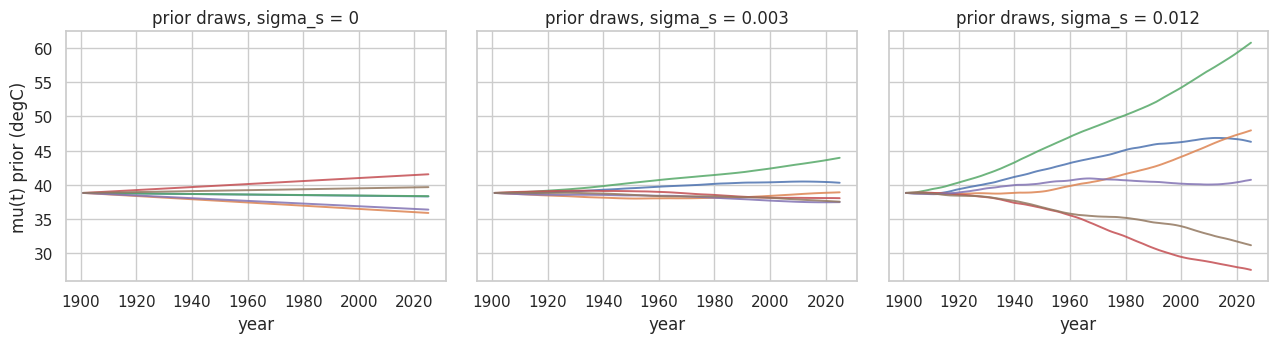

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, sig in zip(axes, (0.0, 0.003, 0.012)):
    for s in range(6):
        key = jr.PRNGKey(s)
        slope0 = 0.02 * jr.normal(key)
        zz = jr.normal(jr.fold_in(key, 1), (n - 1, 2))
        ax.plot(yr, y_mean + np.asarray(llt_trend(slope0, sig, zz)), lw=1.4, alpha=0.85)
    ax.set(xlabel="year", title=f"prior draws, sigma_s = {sig:g}")
axes[0].set_ylabel("mu(t) prior (degC)")
fig.tight_layout()
plt.show()

## The model

The GEV likelihood with the local-linear-trend location. We sample the initial
slope, the slope-diffusion $\sigma_s$ (a tight half-normal — the data may bend the
line but must pay for it), the GEV scale/shape, and the $2(n{-}1)$ non-centered
innovations. NUTS infers the joint posterior over hyperparameters and the path.

In [6]:
def gev_llt(obs):
    mu0 = numpyro.sample("mu0", ndist.Normal(y_mean, 5.0))
    slope0 = numpyro.sample("slope0", ndist.Normal(0.0, 0.05))        # degC/yr
    sigma_s = numpyro.sample("sigma_s", ndist.HalfNormal(0.003))      # slope diffusion
    log_sigma = numpyro.sample("log_sigma", ndist.Normal(np.log(y_std), 0.5))
    xi = numpyro.sample("xi", ndist.Normal(0.0, 0.25))
    z = numpyro.sample("z", ndist.Normal(0, 1).expand([n - 1, 2]).to_event(2))
    f = llt_trend(slope0, sigma_s, z)
    numpyro.sample("obs", GEV(loc=mu0 + f, scale=jnp.exp(log_sigma),
                              concentration=xi), obs=obs)

mcmc = MCMC(NUTS(gev_llt, target_accept_prob=0.95, init_strategy=init_to_median),
            num_warmup=1000, num_samples=1000, num_chains=2,
            chain_method="vectorized", progress_bar=False)
mcmc.run(jr.PRNGKey(0), y)
post = mcmc.get_samples()
n_div = int(mcmc.get_extra_fields()["diverging"].sum())
for k in ("mu0", "slope0", "sigma_s", "xi"):
    s = np.asarray(post[k])
    print(f"{k:9s} median {np.median(s):9.4f}   90% ({np.quantile(s,.05):.4f}, "
          f"{np.quantile(s,.95):.4f})")
print(f"divergences: {n_div} / {post['xi'].size}")

mu0       median   38.0511   90% (37.1815, 38.9862)
slope0    median   -0.0168   90% (-0.0636, 0.0150)
sigma_s   median    0.0039   90% (0.0010, 0.0078)
xi        median   -0.1146   90% (-0.1847, -0.0170)
divergences: 7 / 2000


### Reading the trend

$\sigma_s$ is the **bend budget** — how far the slope may wander from a constant.
It comes out small, so the trend stays close to a line; the warming is summarised
robustly as the difference between the trend's first and last 15-year means.

In [7]:
def ci(a): return np.quantile(a, [0.025, 0.5, 0.975])
NS = 600
sub = jr.choice(jr.PRNGKey(1), post["xi"].size, (NS,), replace=False)
f_draws = jax.vmap(lambda s0, ss, zz: llt_trend(s0, ss, zz))(
    post["slope0"][sub], post["sigma_s"][sub], post["z"][sub])
mu_draws = np.asarray(post["mu0"][sub][:, None] + f_draws)      # (NS, n)
early = mu_draws[:, yr <= yr.min() + 15].mean(1)
late = mu_draws[:, yr >= yr.max() - 15].mean(1)
realized = late - early
rlo, rmd, rhi = ci(realized)
print(f"warming (last 15yr - first 15yr): {rmd:+.2f} degC  (95% CI {rlo:+.2f}, {rhi:+.2f})")
print(f"P(warming > 0 | data) = {float((realized > 0).mean()):.3f}")
print(f"slope-diffusion sigma_s median {np.median(post['sigma_s']):.4f} degC/yr "
      f"(small -> near-linear)")

warming (last 15yr - first 15yr): +1.22 degC  (95% CI +0.26, +2.14)
P(warming > 0 | data) = 0.993
slope-diffusion sigma_s median 0.0039 degC/yr (small -> near-linear)


## The fitted curve

The posterior trend with its credible band. It is a **smooth, gently accelerating
warming** — close to a straight line, with only as much curvature as the data
support. Compare this with a *stationary* Matérn GP fit to the same maxima
(dashed): with a free lengthscale it chases multidecadal wiggles and reverts
between them — visibly over-fitting a record this short. The local linear trend is
the disciplined alternative.

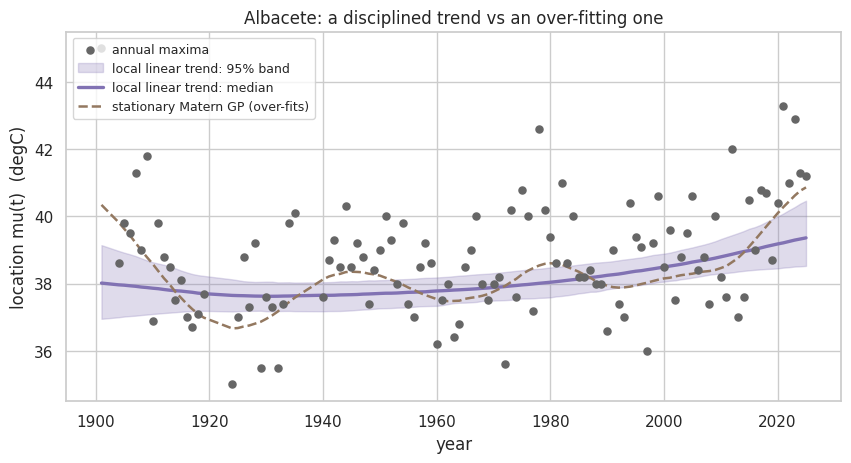

In [8]:
# A stationary Matern-3/2 GP, fit the same way, to show the over-fitting it invites.
def matern32(ell, sigma_f, z2):
    lam = jnp.sqrt(3.0) / ell
    Pinf = sigma_f**2 * jnp.array([[1.0, 0.0], [0.0, lam**2]])
    x0 = jnp.linalg.cholesky(Pinf) @ z2[0]

    def step(xp, inp):
        dt, zk = inp
        e = jnp.exp(-lam * dt)
        A = e * jnp.array([[1.0 + lam * dt, dt], [-lam**2 * dt, 1.0 - lam * dt]])
        Q = Pinf - A @ Pinf @ A.T
        x = A @ xp + jnp.linalg.cholesky(Q + 1e-9 * eye) @ zk
        return x, x[0]

    _, fs = scan(step, x0, (dts, z2[1:]))
    return jnp.concatenate([x0[:1], fs])

def gev_matern(obs):
    mu0 = numpyro.sample("mu0", ndist.Normal(y_mean, 5.0))
    ell = numpyro.sample("ell", ndist.LogNormal(np.log(40.0), 0.6))
    ls = numpyro.sample("log_sigma", ndist.Normal(np.log(y_std), 0.5))
    xi = numpyro.sample("xi", ndist.Normal(0.0, 0.25))
    z2 = numpyro.sample("z2", ndist.Normal(0, 1).expand([n, 2]).to_event(2))
    numpyro.sample("obs", GEV(loc=mu0 + matern32(ell, 2.0, z2),
                              scale=jnp.exp(ls), concentration=xi), obs=obs)
mat = MCMC(NUTS(gev_matern, target_accept_prob=0.95, init_strategy=init_to_median),
           num_warmup=800, num_samples=800, num_chains=2,
           chain_method="vectorized", progress_bar=False)
mat.run(jr.PRNGKey(7), y)
pmat = mat.get_samples()
smat = jr.choice(jr.PRNGKey(8), pmat["xi"].size, (NS,), replace=False)
mu_mat = np.median(np.asarray(pmat["mu0"][smat][:, None] + jax.vmap(
    lambda e, zz: matern32(e, 2.0, zz))(pmat["ell"][smat], pmat["z2"][smat])), 0)

mu_med, mu_lo, mu_hi = (np.quantile(mu_draws, q, 0) for q in (0.5, 0.025, 0.975))
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.scatter(yr, y_np, color="0.4", s=26, zorder=4, label="annual maxima")
ax.fill_between(yr, mu_lo, mu_hi, color="#8172B3", alpha=0.25,
                label="local linear trend: 95% band")
ax.plot(yr, mu_med, color="#8172B3", lw=2.4, label="local linear trend: median")
ax.plot(yr, mu_mat, color="#937860", lw=1.8, ls="--",
        label="stationary Matern GP (over-fits)")
ax.set(xlabel="year", ylabel="location mu(t)  (degC)",
       title=f"{place}: a disciplined trend vs an over-fitting one")
ax.legend(loc="upper left", fontsize=9)
plt.show()

## Line, ODE, and GP on one set of axes

The series in one figure. We refit the linear-location model and the
energy-balance ODE and overlay their median $\mu(t)$ on the local-linear-trend
band. Now that the GP is regularised, the three **agree**: a smooth rise of about
a degree across the century, the GP merely flexing slightly where the ODE and line
cannot.

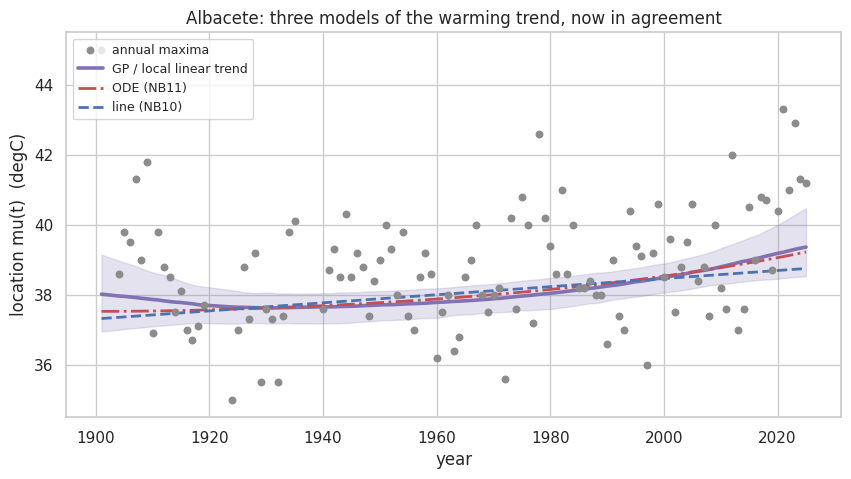

In [9]:
z_lin = (yr - yr.mean()) / yr.std()
zc = jnp.asarray(z_lin)
def gev_lin(obs, zz):
    a = numpyro.sample("a", ndist.Normal(y_mean, 5.0))
    b = numpyro.sample("b", ndist.Normal(0.0, 2.0))
    ls = numpyro.sample("ls", ndist.Normal(np.log(y_std), 0.5))
    xi = numpyro.sample("xi", ndist.Normal(0.0, 0.25))
    numpyro.sample("obs", GEV(loc=a + b * zz, scale=jnp.exp(ls),
                              concentration=xi), obs=obs)
lin = MCMC(NUTS(gev_lin, target_accept_prob=0.99, init_strategy=init_to_median),
           num_warmup=800, num_samples=800, num_chains=2,
           chain_method="vectorized", progress_bar=False)
lin.run(jr.PRNGKey(2), y, zc)
plin = lin.get_samples()
mu_line = np.median(plin["a"]) + np.median(plin["b"]) * z_lin

t0, t1 = float(yr.min()), float(yr.max()); ts = jnp.asarray(yr, float); ALPHA = 2.0
def forcing(t):
    u = (t - t0) / (t1 - t0)
    return (jnp.exp(ALPHA * u) - 1.0) / (jnp.exp(ALPHA) - 1.0)
def integrate(beta, tau, tq):
    def vf(t, T, args): return (beta * forcing(t) - T) / tau
    sol = diffeqsolve(ODETerm(vf), Tsit5(), t0=t0, t1=t1, dt0=0.5, y0=0.0,
                      saveat=SaveAt(ts=tq), stepsize_controller=ConstantStepSize(),
                      max_steps=2000)
    return sol.ys
def gev_ode(obs):
    mu0 = numpyro.sample("mu0", ndist.Normal(y_mean, 5.0))
    beta = numpyro.sample("beta", ndist.Normal(0.0, 3.0))
    tau = numpyro.sample("tau", ndist.LogNormal(np.log(20.0), 0.8))
    ls = numpyro.sample("log_sigma", ndist.Normal(np.log(y_std), 0.5))
    xi = numpyro.sample("xi", ndist.Normal(0.0, 0.25))
    numpyro.sample("obs", GEV(loc=mu0 + integrate(beta, tau, ts),
                              scale=jnp.exp(ls), concentration=xi), obs=obs)
ode = MCMC(NUTS(gev_ode, target_accept_prob=0.95, init_strategy=init_to_median),
           num_warmup=800, num_samples=800, num_chains=2,
           chain_method="sequential", progress_bar=False)
ode.run(jr.PRNGKey(3), y)
pode = ode.get_samples()
mu_ode = np.median(pode["mu0"]) + np.asarray(
    integrate(np.median(pode["beta"]), np.median(pode["tau"]), ts))

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(yr, y_np, color="0.55", s=22, zorder=3, label="annual maxima")
ax.fill_between(yr, mu_lo, mu_hi, color="#8172B3", alpha=0.20)
ax.plot(yr, mu_med, color="#8172B3", lw=2.6, label="GP / local linear trend")
ax.plot(yr, mu_ode, color="#C44E52", lw=2, ls="-.", label="ODE (NB11)")
ax.plot(yr, mu_line, color="#4C72B0", lw=2, ls="--", label="line (NB10)")
ax.set(xlabel="year", ylabel="location mu(t)  (degC)",
       title=f"{place}: three models of the warming trend, now in agreement")
ax.legend(loc="upper left", fontsize=9)
plt.show()

### WAIC across the family

The scorecard. WAIC estimates out-of-sample fit; lower is better. The
local-linear-trend GP still carries latent states, so its score is *mildly*
optimistic — but, unlike the free Matérn GP (whose conditional WAIC plunges far
below the rest by fitting the wiggles in-sample), the disciplined trend lands in a
tight band with the line and ODE. Letting $\mu(t)$ move clearly helps; how you let
it move barely matters here.

In [10]:
def waic(ll):
    S = ll.shape[0]
    lppd = logsumexp(ll, axis=0) - jnp.log(S)
    return float(-2.0 * (lppd.sum() - ll.var(axis=0).sum()))

def gev_stat(obs):
    mu = numpyro.sample("mu", ndist.Normal(y_mean, 5.0))
    sigma = numpyro.sample("sigma", ndist.HalfNormal(y_std))
    xi = numpyro.sample("xi", ndist.Normal(0.0, 0.25))
    numpyro.sample("obs", GEV(loc=mu, scale=sigma, concentration=xi), obs=obs)
stat = MCMC(NUTS(gev_stat, target_accept_prob=0.99, init_strategy=init_to_median),
            num_warmup=800, num_samples=800, num_chains=2,
            chain_method="vectorized", progress_bar=False)
stat.run(jr.PRNGKey(4), y)
pst = stat.get_samples()

ll_stat = gev_log_prob(y[None, :], pst["mu"][:, None], pst["sigma"][:, None], pst["xi"][:, None])
ll_line = gev_log_prob(y[None, :], plin["a"][:, None] + plin["b"][:, None] * zc[None, :],
                       jnp.exp(plin["ls"])[:, None], plin["xi"][:, None])
T_ode = jax.vmap(lambda b, ta: integrate(b, ta, ts))(pode["beta"], pode["tau"])
ll_ode = gev_log_prob(y[None, :], pode["mu0"][:, None] + T_ode,
                      jnp.exp(pode["log_sigma"])[:, None], pode["xi"][:, None])
f_all = jax.vmap(lambda s0, ss, zz: llt_trend(s0, ss, zz))(
    post["slope0"], post["sigma_s"], post["z"])
ll_gp = gev_log_prob(y[None, :], post["mu0"][:, None] + f_all,
                     jnp.exp(post["log_sigma"])[:, None], post["xi"][:, None])
f_mat = jax.vmap(lambda e, zz: matern32(e, 2.0, zz))(pmat["ell"], pmat["z2"])
ll_mat = gev_log_prob(y[None, :], pmat["mu0"][:, None] + f_mat,
                      jnp.exp(pmat["log_sigma"])[:, None], pmat["xi"][:, None])
tab = pd.DataFrame({"WAIC": [waic(ll_stat), waic(ll_line), waic(ll_ode),
                             waic(ll_gp), waic(ll_mat)]},
                   index=["stationary", "line (NB10)", "ODE (NB11)",
                          "GP local-linear", "GP stationary Matern"])
tab["dWAIC"] = tab["WAIC"] - tab["WAIC"].min()
print(tab.round(2).to_string())
print("\n(the stationary-Matern WAIC is the lowest, but that is the in-sample "
      "over-fitting flagged above — not a real predictive win.)")

                        WAIC  dWAIC
stationary            447.91  34.93
line (NB10)           443.21  30.23
ODE (NB11)            439.01  26.03
GP local-linear       436.60  23.61
GP stationary Matern  412.98   0.00

(the stationary-Matern WAIC is the lowest, but that is the in-sample over-fitting flagged above — not a real predictive win.)


## Time-varying return levels

The return level rides the smooth trend. We read it at the GP location for the
first and last years and place each maximum at its own-year climate, coloured by
year — and because the trend no longer wiggles, the cloud now migrates cleanly
from the early envelope up to the recent one.

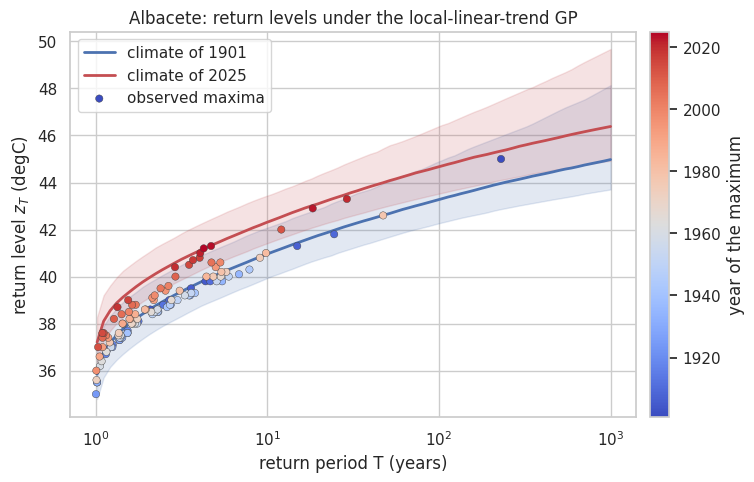

In [11]:
mu0_m = float(np.median(post["mu0"]))
sig_m = float(np.exp(np.median(post["log_sigma"])))
xi_m = float(np.median(post["xi"]))
loc_year = mu0_m + np.median(f_draws, axis=0)
p_t = np.asarray(gev_survival(y, jnp.asarray(loc_year), sig_m, xi_m))
p_t = np.clip(p_t, 0.5 / n, None)
T_own = 1.0 / p_t
t_lo = max(1.02, float(T_own.min()))
periods = jnp.logspace(np.log10(t_lo), 3, 80)

jfirst = int(np.argmin(yr)); jlast = int(np.argmax(yr))
def rl_curve(jyear):
    locs = post["mu0"][sub] + f_draws[:, jyear]
    sig = jnp.exp(post["log_sigma"])[sub]; xi = post["xi"][sub]
    rl = jax.vmap(lambda i: GEV(loc=locs[i], scale=sig[i], concentration=xi[i])
                  .return_level(periods))(jnp.arange(locs.size))
    return np.asarray(rl)

fig, ax = plt.subplots(figsize=(8.8, 5))
for j, c, lab in [(jfirst, "#4C72B0", f"climate of {yr.min()}"),
                  (jlast, "#C44E52", f"climate of {yr.max()}")]:
    rl = rl_curve(j)
    med, lo, hi = (np.quantile(rl, q, 0) for q in (0.5, 0.025, 0.975))
    ax.fill_between(np.asarray(periods), lo, hi, color=c, alpha=0.16)
    ax.plot(np.asarray(periods), med, color=c, lw=2, label=lab)
sc = ax.scatter(T_own, y_np, c=yr, cmap="coolwarm", s=28, zorder=6,
                edgecolor="0.25", linewidth=0.3, label="observed maxima")
fig.colorbar(sc, ax=ax, pad=0.02).set_label("year of the maximum")
ax.set_xscale("log")
ax.set(xlabel="return period T (years)", ylabel=r"return level $z_T$ (degC)",
       title=f"{place}: return levels under the local-linear-trend GP")
ax.legend(loc="upper left")
plt.show()

## Extension: a trend on the scale, too

The same state-space machinery extends to a *second* local-linear trend on the
log-scale, $\log\sigma(t)=s_0+g(t)$, letting the spread of summer maxima drift as
freely as the centre. We give it its own innovations and slope-diffusion and ask
whether the data want it.

In [12]:
def gev_llt2(obs):
    mu0 = numpyro.sample("mu0", ndist.Normal(y_mean, 5.0))
    slope0 = numpyro.sample("slope0", ndist.Normal(0.0, 0.05))
    sig_s = numpyro.sample("sigma_s", ndist.HalfNormal(0.003))
    s0 = numpyro.sample("s0", ndist.Normal(np.log(y_std), 0.5))
    sslope0 = numpyro.sample("sslope0", ndist.Normal(0.0, 0.01))
    sig_g = numpyro.sample("sigma_g", ndist.HalfNormal(0.0010))
    xi = numpyro.sample("xi", ndist.Normal(0.0, 0.25))
    zf = numpyro.sample("zf", ndist.Normal(0, 1).expand([n - 1, 2]).to_event(2))
    zg = numpyro.sample("zg", ndist.Normal(0, 1).expand([n - 1, 2]).to_event(2))
    f = llt_trend(slope0, sig_s, zf)
    g = llt_trend(sslope0, sig_g, zg)
    numpyro.sample("obs", GEV(loc=mu0 + f, scale=jnp.exp(s0 + g),
                              concentration=xi), obs=obs)

mcmc2 = MCMC(NUTS(gev_llt2, target_accept_prob=0.95, init_strategy=init_to_median),
             num_warmup=1000, num_samples=1000, num_chains=2,
             chain_method="vectorized", progress_bar=False)
mcmc2.run(jr.PRNGKey(5), y)
post2 = mcmc2.get_samples()
g_draws = jax.vmap(lambda s0, ss, zz: llt_trend(s0, ss, zz))(
    post2["sslope0"][sub], post2["sigma_g"][sub], post2["zg"][sub])
sig_t = np.asarray(jnp.exp(post2["s0"][sub][:, None] + g_draws))
sig_rng = np.median(sig_t, 0)
f_all2 = jax.vmap(lambda s0, ss, zz: llt_trend(s0, ss, zz))(
    post2["slope0"], post2["sigma_s"], post2["zf"])
g_all2 = jax.vmap(lambda s0, ss, zz: llt_trend(s0, ss, zz))(
    post2["sslope0"], post2["sigma_g"], post2["zg"])
ll_gp2 = gev_log_prob(y[None, :], post2["mu0"][:, None] + f_all2,
                      jnp.exp(post2["s0"][:, None] + g_all2), post2["xi"][:, None])
print(f"sigma(t) spans {sig_rng.min():.2f}-{sig_rng.max():.2f} degC across the record")
print(f"WAIC: trend on mu only {waic(ll_gp):.1f}  |  trend on mu+sigma {waic(ll_gp2):.1f}")
print("scale trend " + ("helps" if waic(ll_gp2) < waic(ll_gp) - 2
      else "is not supported — the spread is effectively constant"))

sigma(t) spans 1.37-1.83 degC across the record
WAIC: trend on mu only 436.6  |  trend on mu+sigma 436.8
scale trend is not supported — the spread is effectively constant


## Recap & series finale

We let the data shape the trend — but with a prior that *defaults to a line*. The
**local linear trend**, an integrated random walk in state-space form
{eq}`eq:sde`, is the stochastic sibling of the previous notebook's ODE and is
walked in $O(n)$ via the Markov recursion {eq}`eq:markov`. Crucially, it is the
*disciplined* GP: a free stationary Matérn kernel over-fits a single short record,
chasing multidecadal noise, while this prior bends only as much as the data buy.

With that discipline, the three trend models **agree**: a smooth warming of about
a degree across the century, return levels today well above 1901's, and a tail
shape $\xi$ the data place consistently across all of them. The line, the ODE, and
the GP differ most where data are thinnest — the GP simply reports wider
uncertainty there. The reassuring lesson is that the warming signal is robust to
the model of the trend; the caution is that flexibility, unregularised, will
manufacture structure that is not there.

**The series.** From a single GEV fit ([](../01_evt_foundations/02_gev_one_station.ipynb))
we pooled across *space* (hierarchies and spatial GPs, NB04–09) and then let the
parameters move through *time* at one station, three ways (NB10–12). The natural
synthesis is a field that varies over **space and time together** — a
spatio-temporal GP on the GEV parameters, the state-space trick of this notebook
running along the time axis at every site of the spatial models. That is where a
modern non-stationary extremes model lives.